# Section 2: Customizing Models and Training Algorithms

### 2.1 Custom Loss Functions

In [1]:
# Load dataset
from tensorflow.keras.datasets import boston_housing

feature_names_descriptions = {
    "CRIM": "per capita crime rate by town",
    "ZN": "proportion of residential land zoned for lots over 25,000 sq.ft.",
    "INDUS": "proportion of non-retail business acres per town.",
    "CHAS": "Charles River dummy variable (1 if tract bounds river; 0 otherwise)",
    "NOX": "nitric oxides concentration (parts per 10 million)",
    "RM": "average number of rooms per dwelling",
    "AGE": "proportion of owner-occupied units built prior to 1940",
    "DIS": "weighted distances to five Boston employment centres",
    "RAD": "index of accessibility to radial highways",
    "TAX": "full-value property-tax rate per $10,000",
    "PTRATIO": "pupil-teacher ratio by town",
    "B": "1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town",
    "LSTAT": "% lower status of the population",
    "MEDV": "Median value of owner-occupied homes in $1000's",
}
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

In [2]:
# Shape
import numpy as np
import pandas as pd

ids = pd.MultiIndex.from_product([["train", "test"], ["X", "Y"]])
data_shapes = map(np.shape, [x_train, y_train, x_train, y_test])
df_dataset_shape = pd.Series(data_shapes, index=ids, name="shape")
df_dataset_shape

train  X    (404, 13)
       Y       (404,)
test   X    (404, 13)
       Y       (102,)
Name: shape, dtype: object

In [3]:
# Data
df_train = pd.DataFrame(
    data=np.c_[x_train, y_train], columns=feature_names_descriptions.keys()
)
df_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72,15.2
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11,42.3
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26,50.0
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01,21.1
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65,17.7


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     404 non-null    float64
 1   ZN       404 non-null    float64
 2   INDUS    404 non-null    float64
 3   CHAS     404 non-null    float64
 4   NOX      404 non-null    float64
 5   RM       404 non-null    float64
 6   AGE      404 non-null    float64
 7   DIS      404 non-null    float64
 8   RAD      404 non-null    float64
 9   TAX      404 non-null    float64
 10  PTRATIO  404 non-null    float64
 11  B        404 non-null    float64
 12  LSTAT    404 non-null    float64
 13  MEDV     404 non-null    float64
dtypes: float64(14)
memory usage: 44.3 KB


In [5]:
# Statistics
df_train.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.745111,11.480198,11.104431,0.061881,0.557356,6.267082,69.010644,3.740271,9.440594,405.898515,18.475990,354.783168,12.740817,22.395050
std,9.240734,23.767711,6.811308,0.241238,0.117293,0.709788,27.940665,2.030215,8.698360,166.374543,2.200382,94.111148,7.254545,9.210442
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,188.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081437,0.000000,5.130000,0.000000,0.453000,5.874750,45.475000,2.077100,4.000000,279.000000,17.225000,374.672500,6.890000,16.675000
50%,0.268880,0.000000,9.690000,0.000000,0.538000,6.198500,78.500000,3.142300,5.000000,330.000000,19.100000,391.250000,11.395000,20.750000
75%,3.674808,12.500000,18.100000,0.000000,0.631000,6.609000,94.100000,5.118000,24.000000,666.000000,20.200000,396.157500,17.092500,24.800000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.725000,100.000000,10.710300,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


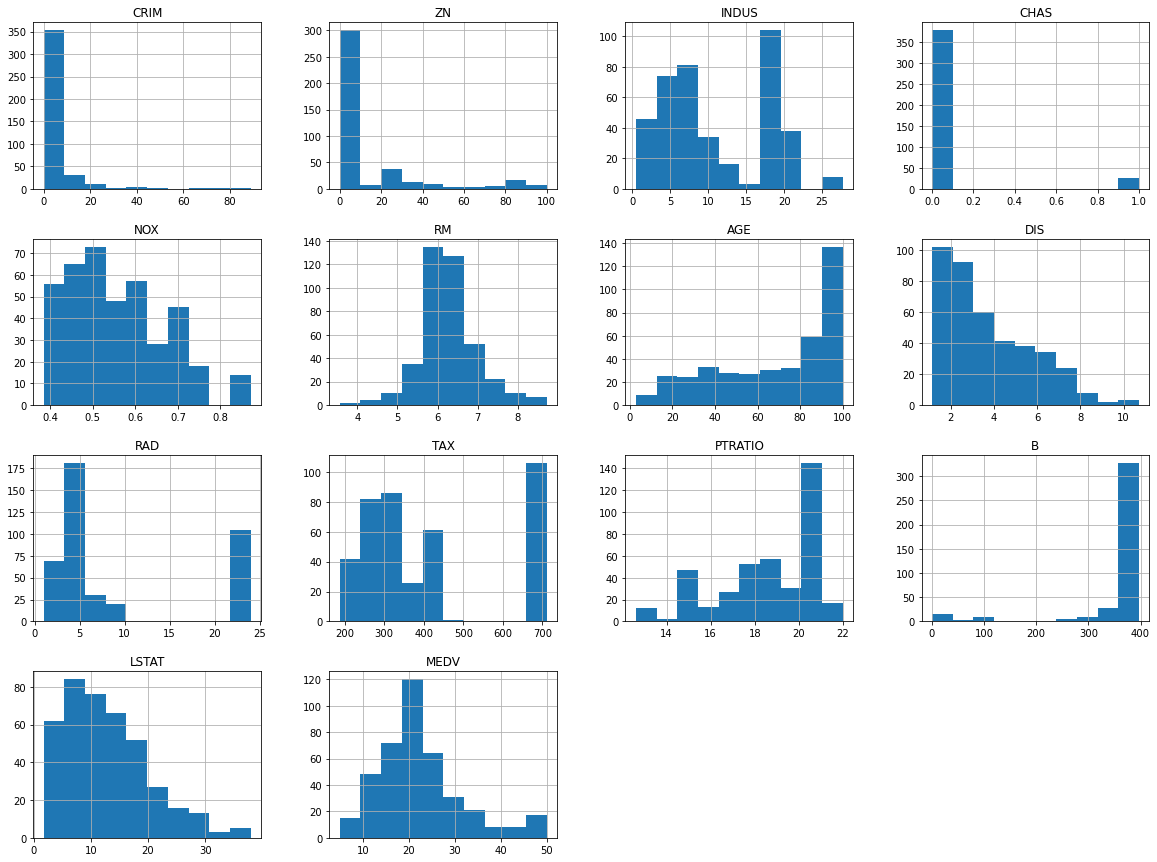

In [6]:
# Histogram
%matplotlib inline
import matplotlib.pyplot as plt

df_train.hist(figsize=(20, 15))
plt.show()

In [7]:
corr_matrix = df_train.corr()
corr_matrix["MEDV"].sort_values(ascending=False)

MEDV       1.000000
RM         0.681483
ZN         0.380299
B          0.343953
DIS        0.253900
CHAS       0.168661
AGE       -0.364173
RAD       -0.375515
CRIM      -0.378498
NOX       -0.438328
TAX       -0.448737
INDUS     -0.476743
PTRATIO   -0.493990
LSTAT     -0.730793
Name: MEDV, dtype: float64

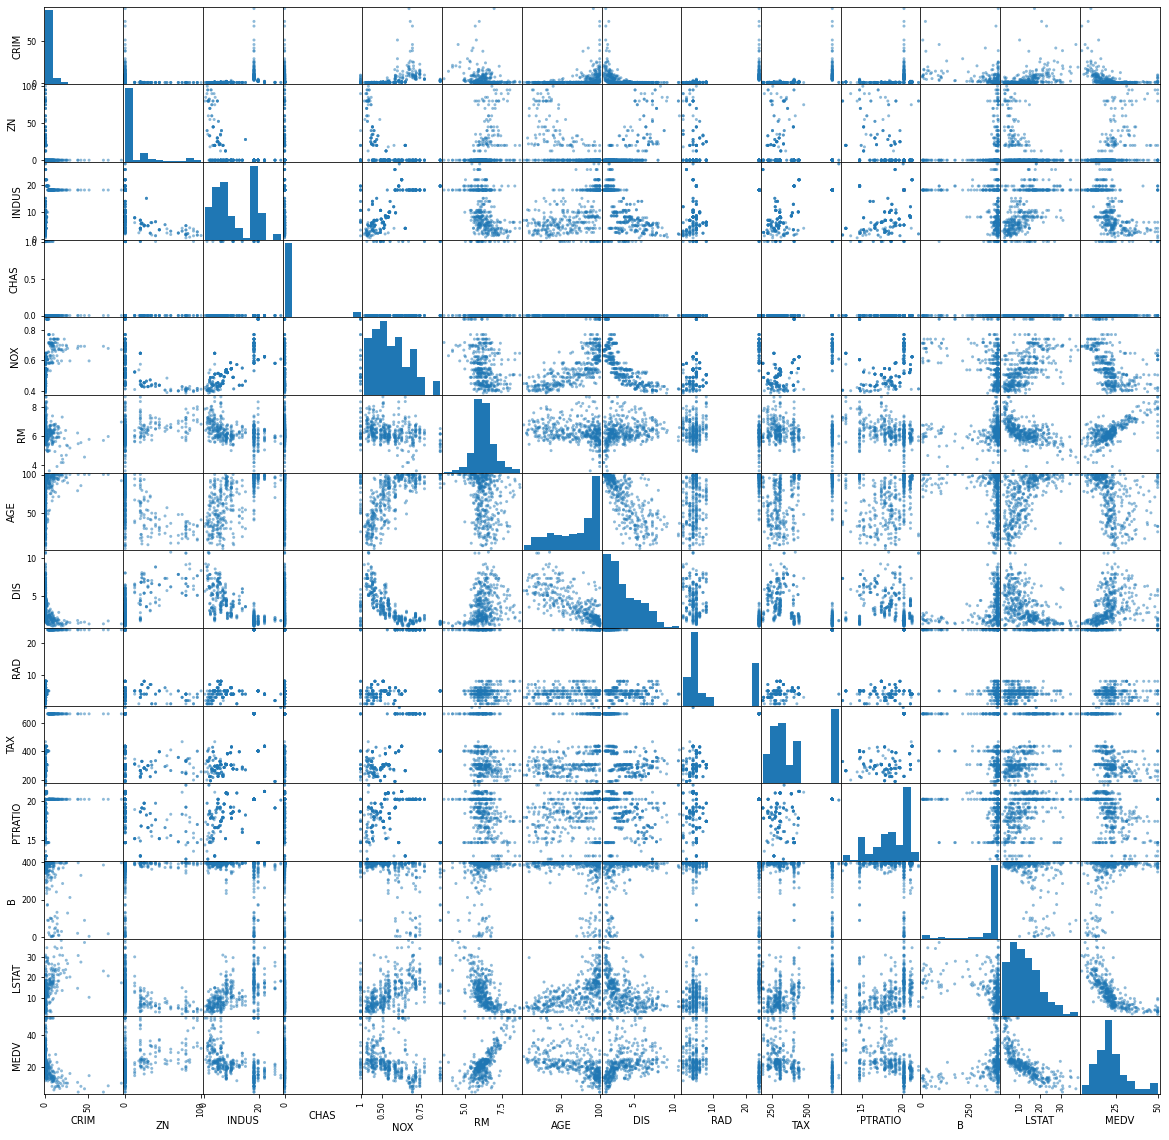

In [8]:
from pandas.plotting import scatter_matrix

scatter_matrix(df_train, figsize=(20, 20))
plt.show()

In [9]:
# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_norm = scaler.fit_transform(x_train)
pd.DataFrame(
    x_train_norm, columns=list(feature_names_descriptions.keys())[:-1]
).describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02
mean,-1.015414e-16,1.099231e-17,1.743380e-15,-1.266863e-16,-5.253773e-15,6.414149e-15,2.984411e-16,4.946538e-16,1.126711e-17,-1.981363e-16,2.366864e-14,5.956800e-15,6.139204e-16
std,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00
min,-4.051005e-01,-4.836155e-01,-1.564696e+00,-2.568327e-01,-1.471269e+00,-3.817250e+00,-2.369042e+00,-1.287503e+00,-9.715693e-01,-1.311311e+00,-2.673752e+00,-3.771101e+00,-1.519664e+00
25%,-3.969615e-01,-4.836155e-01,-8.782218e-01,-2.568327e-01,-8.908055e-01,-5.534305e-01,-8.433882e-01,-8.202251e-01,-6.262491e-01,-7.636737e-01,-5.692381e-01,2.116008e-01,-8.075036e-01
50%,-3.766520e-01,-4.836155e-01,-2.079167e-01,-2.568327e-01,-1.652266e-01,-9.674263e-02,3.400464e-01,-2.949009e-01,-5.111423e-01,-4.567563e-01,2.839433e-01,3.879673e-01,-1.857436e-01
75%,-7.617386e-03,4.296024e-02,1.028326e+00,-2.568327e-01,6.286420e-01,4.823165e-01,8.990647e-01,6.794540e-01,1.675886e+00,1.565287e+00,7.844764e-01,4.401777e-01,6.005999e-01
max,9.234847e+00,3.728990e+00,2.445374e+00,3.893584e+00,2.677335e+00,3.467186e+00,1.110488e+00,3.437406e+00,1.675886e+00,1.836097e+00,1.603531e+00,4.480771e-01,3.482019e+00


In [10]:
# Function to copy model
from copy import deepcopy
from tensorflow.keras import Model
from tensorflow.keras.models import clone_model


def copy_model(model: Model) -> Model:
    model_copy = clone_model(model)
    model_copy.set_weights(deepcopy(model.get_weights()))
    return model_copy

In [11]:
# Create model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential(
    [
        Dense(
            3,
            activation="selu",
            kernel_initializer="lecun_normal",
            input_shape=x_train_norm.shape[1:],
        ),
        Dense(1, activation=None),
    ]
)
model.compile(optimizer="rmsprop", loss="mean_squared_error")
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 3)                 42        
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 4         
Total params: 46
Trainable params: 46
Non-trainable params: 0
_________________________________________________________________


In [12]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6006

Launching TensorBoard...

In [13]:
# Function to generate a new logging directory
def dir_log() -> str:
    return str(Path() / "my_logs" / time.strftime("run_%Y_%m_%d-%H_%M_%S"))

In [14]:
# Train the model
import time
from pathlib import Path
from tensorflow.keras.callbacks import TensorBoard

model_orig = copy_model(model)
model_orig.compile(loss="mean_squared_error")
model_orig.fit(
    x_train_norm,
    y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[TensorBoard(dir_log())],
)

Epoch 1/1000
11/11 [==============================] - 1s 41ms/step - loss: 556.0790 - val_loss: 635.3057
Epoch 2/1000
11/11 [==============================] - 0s 4ms/step - loss: 560.3381 - val_loss: 632.5822
Epoch 3/1000
11/11 [==============================] - 0s 5ms/step - loss: 566.4436 - val_loss: 630.0495
Epoch 4/1000
11/11 [==============================] - 0s 5ms/step - loss: 553.0277 - val_loss: 627.3588
Epoch 5/1000
11/11 [==============================] - 0s 4ms/step - loss: 516.2783 - val_loss: 624.7621
Epoch 6/1000
11/11 [==============================] - 0s 6ms/step - loss: 574.3803 - val_loss: 622.2927
Epoch 7/1000
11/11 [==============================] - 0s 5ms/step - loss: 577.8127 - val_loss: 619.7925
Epoch 8/1000
11/11 [==============================] - 0s 5ms/step - loss: 536.8530 - val_loss: 617.2000
Epoch 9/1000
11/11 [==============================] - 0s 5ms/step - loss: 584.5014 - val_loss: 614.6981
Epoch 10/1000
11/11 [==============================] - 0s 5ms/s

In [15]:
# Evaluate
model_orig.evaluate(scaler.transform(x_test), y_test)

4/4 [==============================] - 0s 1ms/step - loss: 14.7934


14.793357849121094

In [16]:
# Custom loss function
import tensorflow as tf

# def huber(y_true: np.ndarray, y_pred: np.ndarray):
#     error = y_true - y_pred
#     is_small_error = tf.abs(error) < 1
#     loss_squared = tf.square(error) / 2
#     loss_linear = tf.abs(error) - 0.5
#     return tf.where(is_small_error, loss_squared, loss_linear)


class HuberLoss(tf.keras.losses.Loss):
    def __init__(self, threshold: float = 1.0, **kwargs):
        self.threshold = threshold
        super().__init__(**kwargs)

    def call(self, y_true: np.ndarray, y_pred: np.ndarray):
        error = y_true - y_pred
        is_small_error = error < self.threshold
        loss_squared = tf.square(error) / 2
        loss_linear = self.threshold * tf.abs(error) - self.threshold**2 / 2
        return tf.where(is_small_error, loss_squared, loss_linear)

    def get_config(self):
        return {**super().get_config(), "threshold": self.threshold}

In [17]:
# Train a new model
model_huber = copy_model(model)
model_huber.compile(loss=HuberLoss())
model_huber.fit(
    x_train_norm,
    y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[TensorBoard(dir_log())],
)

Epoch 1/1000
11/11 [==============================] - 1s 19ms/step - loss: 22.0106 - val_loss: 23.2372
Epoch 2/1000
11/11 [==============================] - 0s 5ms/step - loss: 21.9162 - val_loss: 23.1764
Epoch 3/1000
11/11 [==============================] - 0s 6ms/step - loss: 22.3864 - val_loss: 23.1223
Epoch 4/1000
11/11 [==============================] - 0s 6ms/step - loss: 21.5611 - val_loss: 23.0718
Epoch 5/1000
11/11 [==============================] - 0s 4ms/step - loss: 21.6819 - val_loss: 23.0243
Epoch 6/1000
11/11 [==============================] - 0s 5ms/step - loss: 21.9438 - val_loss: 22.9726
Epoch 7/1000
11/11 [==============================] - 0s 6ms/step - loss: 22.0490 - val_loss: 22.9214
Epoch 8/1000
11/11 [==============================] - 0s 6ms/step - loss: 21.9145 - val_loss: 22.8709
Epoch 9/1000
11/11 [==============================] - 0s 5ms/step - loss: 22.4301 - val_loss: 22.8213
Epoch 10/1000
11/11 [==============================] - 0s 5ms/step - loss: 21.391

In [18]:
# Evaluate
model_huber.evaluate(scaler.transform(x_test), y_test)

4/4 [==============================] - 0s 4ms/step - loss: 3.6476


3.64756178855896

In [19]:
# Save model
from tensorflow.keras.models import save_model

path_model_h5 = Path() / "model_huber.h5"
save_model(model_huber, path_model_h5)

In [20]:
# Load model
from tensorflow.keras.models import load_model

model_huber_load = load_model(path_model_h5, custom_objects={"HuberLoss": HuberLoss})
model_huber_load.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 3)                 42        
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 4         
Total params: 46
Trainable params: 46
Non-trainable params: 0
_________________________________________________________________


### 2.2 Saving and Loading Models That Contain Custom Components

In [21]:
model.get_weights()

[array([[ 0.17580673, -0.04931425,  0.32439995],
        [-0.08405884, -0.31238824, -0.47412735],
        [ 0.02441215,  0.05099866,  0.32538313],
        [-0.16181013,  0.10926969,  0.18931325],
        [ 0.27354488,  0.09369268,  0.11763208],
        [ 0.52024704, -0.28264678,  0.03067927],
        [ 0.17073196, -0.09603853,  0.20189816],
        [ 0.5731287 , -0.04518748, -0.24552418],
        [ 0.30948484, -0.34598902,  0.4087514 ],
        [-0.11186761,  0.03467571,  0.57971793],
        [ 0.11775538, -0.13339752,  0.10265163],
        [ 0.36635056, -0.16226104, -0.23268448],
        [-0.12249824, -0.08418716,  0.5987022 ]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[-0.3493085],
        [ 0.6275525],
        [-1.0508568]], dtype=float32),
 array([0.], dtype=float32)]

### 2.3 Custom Activation Functions, Initializers, Regularizers, and Constraints

##### Activation functions
Example: softplus

In [22]:
import numpy as np
import tensorflow as tf
from typing import Union


def my_softplus(x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
    return tf.math.log(tf.math.exp(x) + 1)


x = tf.constant([-100, 0, 1, 100, 1000], dtype=tf.float32)
print(tf.nn.softplus(x))
print(my_softplus(x))

tf.Tensor([0.0000000e+00 6.9314718e-01 1.3132616e+00 1.0000000e+02 1.0000000e+03], shape=(5,), dtype=float32)
tf.Tensor([0.        0.6931472 1.3132616       inf       inf], shape=(5,), dtype=float32)


##### Initializers
Example: Glorot normal

In [23]:
from typing import Tuple


def my_glorot_normal(shape: Tuple[int, int], dtype: tf.DType = tf.float32) -> tf.Tensor:
    return tf.random.normal(shape, stddev=tf.sqrt(2 / (shape[0] + shape[1])))


shape = 3, 2
print(tf.initializers.GlorotNormal()(shape))
print(my_glorot_normal(shape))

tf.Tensor(
[[ 0.46945602 -0.5679965 ]
 [-0.93347144 -1.1097064 ]
 [ 0.87172294  0.04984687]], shape=(3, 2), dtype=float32)
tf.Tensor(
[[-0.26825932  0.03685236]
 [-0.13541624 -0.01596851]
 [-0.5524026   1.2539067 ]], shape=(3, 2), dtype=float32)


##### Regularizers
Example: L1 regularizer

In [24]:
from tensorflow import keras


def my_l1_regularizer(weights: tf.Tensor, l1_factor: float = 0.01) -> tf.float32:
    return tf.reduce_sum(tf.abs(l1_factor * weights))


weights = tf.reshape(tf.range(6, dtype=tf.float32), [2, 3])
print(weights)
print(keras.regularizers.L1()(weights))
print(my_l1_regularizer(weights))

tf.Tensor(
[[0. 1. 2.]
 [3. 4. 5.]], shape=(2, 3), dtype=float32)
tf.Tensor(0.14999999, shape=(), dtype=float32)
tf.Tensor(0.14999999, shape=(), dtype=float32)


##### Constraints
Example: positive weights

In [25]:
def my_positive_weights(weights: tf.Tensor) -> tf.Tensor:
    return tf.where(weights < 0.0, tf.zeros_like(weights, dtype=tf.float32), weights)


weights = tf.reshape(tf.range(-3, 3, dtype=tf.float32), (2, 3))
print(weights)
print(tf.nn.relu(weights))
print(my_positive_weights(weights))

tf.Tensor(
[[-3. -2. -1.]
 [ 0.  1.  2.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[0. 0. 0.]
 [0. 1. 2.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[0. 0. 0.]
 [0. 1. 2.]], shape=(2, 3), dtype=float32)


##### Train a model

In [26]:
model_custom = Sequential(
    [
        Dense(
            3,
            activation=my_softplus,
            kernel_initializer=my_glorot_normal,
            kernel_regularizer=my_l1_regularizer,
            kernel_constraint=my_positive_weights,
            input_shape=x_train_norm.shape[1:],
        ),
        Dense(1, activation=None),
    ]
)
model_custom.compile(
    optimizer="rmsprop", loss="mean_squared_error", metrics=[HuberLoss(2.0)]
)
model_custom.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_2 (Dense)              (None, 3)                 42        
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 4         
Total params: 46
Trainable params: 46
Non-trainable params: 0
_________________________________________________________________


In [27]:
model_custom.fit(
    x_train_norm,
    y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[TensorBoard(dir_log())],
)
print(model_custom.metrics_names)
model_custom.evaluate(scaler.transform(x_test), y_test)

Epoch 1/1000
11/11 [==============================] - 1s 24ms/step - loss: 574.9513 - mean_metric_wrapper: 42.3906 - val_loss: 651.4916 - val_mean_metric_wrapper: 44.5393
Epoch 2/1000
11/11 [==============================] - 0s 6ms/step - loss: 585.5264 - mean_metric_wrapper: 42.7623 - val_loss: 648.8337 - val_mean_metric_wrapper: 44.4303
Epoch 3/1000
11/11 [==============================] - 0s 6ms/step - loss: 591.9878 - mean_metric_wrapper: 43.1098 - val_loss: 646.2822 - val_mean_metric_wrapper: 44.3311
Epoch 4/1000
11/11 [==============================] - 0s 6ms/step - loss: 537.1746 - mean_metric_wrapper: 41.2706 - val_loss: 643.6630 - val_mean_metric_wrapper: 44.2368
Epoch 5/1000
11/11 [==============================] - 0s 7ms/step - loss: 535.1151 - mean_metric_wrapper: 41.2013 - val_loss: 641.0178 - val_mean_metric_wrapper: 44.1353
Epoch 6/1000
11/11 [==============================] - 0s 6ms/step - loss: 544.7213 - mean_metric_wrapper: 41.5352 - val_loss: 638.5778 - val_mean_met

[33.302757263183594, 28.631139755249023]

In [28]:
print(model_custom.metrics_names)

['loss', 'mean_metric_wrapper']


### 2.4 Custom Metrics

##### Property of Metrics

In [29]:
precision = keras.metrics.Precision()
print(precision([0, 1, 1, 1, 0, 1, 1, 1], [1, 1, 0, 1, 0, 1, 0, 1]))
print(precision.result())
print(precision.variables)

tf.Tensor(0.8, shape=(), dtype=float32)
tf.Tensor(0.8, shape=(), dtype=float32)
[<tf.Variable 'true_positives:0' shape=(1,) dtype=float32, numpy=array([4.], dtype=float32)>, <tf.Variable 'false_positives:0' shape=(1,) dtype=float32, numpy=array([1.], dtype=float32)>]


In [30]:
print(precision([0, 1, 0, 0, 1, 0, 1, 1], [1, 0, 1, 1, 0, 0, 0, 0]))
print(precision.result())
print(precision.variables)

tf.Tensor(0.5, shape=(), dtype=float32)
tf.Tensor(0.5, shape=(), dtype=float32)
[<tf.Variable 'true_positives:0' shape=(1,) dtype=float32, numpy=array([4.], dtype=float32)>, <tf.Variable 'false_positives:0' shape=(1,) dtype=float32, numpy=array([4.], dtype=float32)>]


##### Custom Huber Metric

In [31]:
from typing import Any, Dict


class HuberMetric(keras.metrics.Metric):
    def __init__(self, threshold: float = 1.0, **kwargs):
        super().__init__(**kwargs)  # handles base args (e.g., dtype)
        self.threshold = threshold
        self.huber_fn = HuberLoss(threshold)
        self.total = self.add_weight("total", initializer="zeros")
        self.count = self.add_weight("count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None) -> None:
        metric = self.huber_fn(y_true, y_pred)
        self.total.assign_add(tf.reduce_sum(metric))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self) -> tf.Tensor:
        return self.total / self.count

    def get_config(self) -> Dict[str, Any]:
        return {**super().get_config(), "threshold": self.threshold}


model_custom = Sequential(
    [
        Dense(
            3,
            activation=my_softplus,
            kernel_initializer=my_glorot_normal,
            kernel_regularizer=my_l1_regularizer,
            kernel_constraint=my_positive_weights,
            input_shape=x_train_norm.shape[1:],
        ),
        Dense(1, activation=None),
    ]
)
model_custom.compile(
    optimizer="rmsprop", loss="mean_squared_error", metrics=[HuberMetric(2.0)]
)
model_custom.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 3)                 42        
_________________________________________________________________
dense_5 (Dense)              (None, 1)                 4         
Total params: 46
Trainable params: 46
Non-trainable params: 0
_________________________________________________________________


In [32]:
model_custom.fit(
    x_train_norm,
    y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[TensorBoard(dir_log())],
)
print(model_custom.metrics_names)
model_custom.evaluate(scaler.transform(x_test), y_test)

Epoch 1/1000
11/11 [==============================] - 1s 28ms/step - loss: 567.8158 - huber_metric: 1.3531 - val_loss: 643.5366 - val_huber_metric: 1.6438
Epoch 2/1000
11/11 [==============================] - 0s 6ms/step - loss: 543.9040 - huber_metric: 1.3149 - val_loss: 641.1288 - val_huber_metric: 1.6395
Epoch 3/1000
11/11 [==============================] - 0s 6ms/step - loss: 579.1010 - huber_metric: 1.3517 - val_loss: 638.7822 - val_huber_metric: 1.6357
Epoch 4/1000
11/11 [==============================] - 0s 6ms/step - loss: 568.2206 - huber_metric: 1.3330 - val_loss: 636.6249 - val_huber_metric: 1.6320
Epoch 5/1000
11/11 [==============================] - 0s 6ms/step - loss: 567.3204 - huber_metric: 1.3464 - val_loss: 634.2857 - val_huber_metric: 1.6278
Epoch 6/1000
11/11 [==============================] - 0s 6ms/step - loss: 541.6608 - huber_metric: 1.3083 - val_loss: 632.0980 - val_huber_metric: 1.6241
Epoch 7/1000
11/11 [==============================] - 0s 6ms/step - loss: 5

[32.7993049621582, 1.0308194160461426]

### 2.5 Custom Layers

##### Example 1: exponential layer

In [33]:
import tensorflow as tf
from tensorflow import keras

exponential_layer = keras.layers.Lambda(lambda x: tf.exp(x))

x = tf.range(3.0)
exponential_layer(x)

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1.       , 2.7182817, 7.389056 ], dtype=float32)>

##### Example 2: dense layer

In [34]:
from typing import Optional


class MyDense(keras.layers.Layer):
    def __init__(
        self,
        units: int,
        activation: Optional[Union[str, keras.layers.Activation]],
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, batch_input_shape: tf.TensorShape) -> None:
        self.kernel_ = self.add_weight(
            name="kernel",
            shape=[batch_input_shape[-1], self.units],
            initializer="glorot_normal",
        )
        self.bias_ = self.add_weight(
            name="bias", shape=[self.units], initializer="zeros"
        )
        super().build(batch_input_shape)

    def call(self, inputs: tf.Tensor, **kwargs):
        return self.activation(inputs @ self.kernel_ + self.bias_)

    def compute_output_shape(self, batch_input_shape: tf.TensorShape) -> tf.TensorShape:
        return tf.TensorShape(batch_input_shape.as_list()[:-1] + [self.units])

    def get_config(self) -> Dict[str, Any]:
        return {
            **super().get_config(),
            "units": self.units,
            "activation": keras.activations.serialize(self.activation),
        }

In [35]:
model = Sequential([MyDense(3, "relu"), MyDense(1, None)])
model.compile(loss="mean_squared_error")
model.fit(
    x_train_norm,
    y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[TensorBoard(dir_log())],
)
model.evaluate(scaler.transform(x_test), y_test)

Epoch 1/1000
11/11 [==============================] - 1s 26ms/step - loss: 513.8552 - val_loss: 593.4149
Epoch 2/1000
11/11 [==============================] - 0s 7ms/step - loss: 550.6791 - val_loss: 587.7507
Epoch 3/1000
11/11 [==============================] - 0s 6ms/step - loss: 537.0339 - val_loss: 582.9210
Epoch 4/1000
11/11 [==============================] - 0s 6ms/step - loss: 519.4493 - val_loss: 577.1185
Epoch 5/1000
11/11 [==============================] - 0s 7ms/step - loss: 491.7486 - val_loss: 571.7591
Epoch 6/1000
11/11 [==============================] - 0s 6ms/step - loss: 490.5322 - val_loss: 565.8128
Epoch 7/1000
11/11 [==============================] - 0s 7ms/step - loss: 490.1384 - val_loss: 560.6468
Epoch 8/1000
11/11 [==============================] - 0s 6ms/step - loss: 490.8882 - val_loss: 554.7837
Epoch 9/1000
11/11 [==============================] - 0s 6ms/step - loss: 489.2967 - val_loss: 549.0010
Epoch 10/1000
11/11 [==============================] - 0s 6ms/s

22.60938262939453

##### Example 3: Gaussian noise

In [36]:
class MyGaussianNoise(keras.layers.Layer):
    def __init__(self, stddev: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs: tf.Tensor, train=None, **kwargs) -> tf.Tensor:
        if train:
            return inputs + tf.random.normal(shape=tf.shape(inputs), stddev=self.stddev)
        else:
            return inputs

    def compute_output_shape(self, batch_input_shape: tf.TensorShape) -> tf.TensorShape:
        return batch_input_shape

In [37]:
model = Sequential(
    [
        MyGaussianNoise(input_shape=x_train_norm.shape[1:]),
        Dense(3, activation="selu", kernel_initializer="lecun_normal"),
        Dense(1, activation=None),
    ]
)
model.compile(optimizer="rmsprop", loss="mean_squared_error")
model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
my_gaussian_noise (MyGaussia (None, 13)                0         
_________________________________________________________________
dense_6 (Dense)              (None, 3)                 42        
_________________________________________________________________
dense_7 (Dense)              (None, 1)                 4         
Total params: 46
Trainable params: 46
Non-trainable params: 0
_________________________________________________________________


In [38]:
model.fit(
    x_train_norm,
    y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[TensorBoard(dir_log())],
)
model.evaluate(scaler.transform(x_test), y_test)

Epoch 1/1000
11/11 [==============================] - 1s 42ms/step - loss: 565.5978 - val_loss: 620.4000
Epoch 2/1000
11/11 [==============================] - 0s 10ms/step - loss: 573.4587 - val_loss: 615.6638
Epoch 3/1000
11/11 [==============================] - 0s 9ms/step - loss: 566.2148 - val_loss: 610.9568
Epoch 4/1000
11/11 [==============================] - 0s 12ms/step - loss: 546.6498 - val_loss: 606.7235
Epoch 5/1000
11/11 [==============================] - 0s 11ms/step - loss: 554.5639 - val_loss: 602.2692
Epoch 6/1000
11/11 [==============================] - 0s 8ms/step - loss: 568.6170 - val_loss: 598.3154
Epoch 7/1000
11/11 [==============================] - 0s 10ms/step - loss: 527.2062 - val_loss: 594.0223
Epoch 8/1000
11/11 [==============================] - 0s 7ms/step - loss: 505.2540 - val_loss: 589.7672
Epoch 9/1000
11/11 [==============================] - 0s 7ms/step - loss: 517.6107 - val_loss: 585.0988
Epoch 10/1000
11/11 [==============================] - 0s 6

24.076705932617188

### 2.6 Custom Models

In [39]:
import tensorflow as tf
from tensorflow import keras
from typing import Any, Dict


class ResidualBlock(keras.layers.Layer):
    def __init__(self, n_layers: int, n_neurons: int, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)
        self.hidden_layers = [
            keras.layers.Dense(
                n_neurons, activation="elu", kernel_initializer="he_normal"
            )
            for _ in range(n_layers)
        ]

    def call(self, inputs, **kwargs) -> tf.Tensor:
        x = inputs
        for hidden_layer in self.hidden_layers:
            x = hidden_layer(x)

        return x + inputs

    def get_config(self) -> Dict[str, Any]:
        base_config = super().get_config()
        return {
            **base_config,
            "n_layers": len(self.hidden_layers),
            "n_neurons": self.hidden_layers[0].units,
        }

In [40]:
class ResidualRegressor(keras.Model):
    def __init__(self, output_dim: int, hidden_dim: int = 30, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = keras.layers.Dense(
            hidden_dim, activation="elu", kernel_initializer="he_normal"
        )
        self.residual_block1 = ResidualBlock(2, hidden_dim)
        self.residual_block2 = ResidualBlock(2, hidden_dim)
        self.dense2 = keras.layers.Dense(output_dim)

    def call(self, inputs, training=None, mask=None) -> tf.Tensor:
        z = self.dense1(inputs)
        for _ in range(1 + 3):
            z = self.residual_block1(z)
        z = self.residual_block2(z)
        return self.dense2(z)

    def get_config(self) -> Dict[str, Any]:
        base_config = super().get_config()
        return {
            **base_config,
            "output_dim": self.dense2.units,
            "hidden_dim": self.dense1.units,
        }

In [41]:
model = ResidualRegressor(2)
model.compute_output_shape(input_shape=[1000, 64])
model.summary()

Model: "residual_regressor"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_8 (Dense)              multiple                  1950      
_________________________________________________________________
residual_block (ResidualBloc multiple                  1860      
_________________________________________________________________
residual_block_1 (ResidualBl multiple                  1860      
_________________________________________________________________
dense_13 (Dense)             multiple                  62        
Total params: 5,732
Trainable params: 5,732
Non-trainable params: 0
_________________________________________________________________


In [42]:
import numpy as np

inputs = np.asarray([np.random.normal(size=64)])
model.predict(inputs)

array([[-21.007195 ,  -2.7067926]], dtype=float32)

In [43]:
path_model_h5 = "model"
model.save(path_model_h5, save_format="tf")
model = keras.models.load_model(path_model_h5)
model.predict(inputs)

INFO:tensorflow:Assets written to: model/assets


INFO:tensorflow:Assets written to: model/assets


array([[-21.007195 ,  -2.7067926]], dtype=float32)

### 2.7 Losses and Metrics Based on Model Internals

In [44]:
# from typing import Tuple
#
# class MSE(keras.layers.Layer):
#     def call(self, inputs: Tuple[tf.Tensor, tf.Tensor], **kwargs) -> tf.Tensor:
#         return tf.reduce_mean(tf.square(inputs[0] - inputs[1]))
#
#     def compute_output_shape(self, batch_input_shape: tf.TensorShape) -> tf.TensorShape:
#         shape_recon, shape_pred = batch_input_shape
#         return shape_recon

In [45]:
tf.compat.v1.disable_eager_execution()


class ReconstructingRegressor(keras.Model):
    def __init__(self, output_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.output_dim = output_dim
        self.hidden_layers = [
            keras.layers.Dense(10, activation="selu", kernel_initializer="lecun_normal")
            for _ in range(2)
        ]
        self.output_layer = keras.layers.Dense(self.output_dim)

    def build(self, batch_input_shape):
        self.reconstruction_layer_ = keras.layers.Dense(batch_input_shape[-1])
        super().build(batch_input_shape)

    def call(self, inputs, training=None, mask=None) -> tf.Tensor:
        z = inputs
        for layer in self.hidden_layers:
            z = layer(z)
        reconstruction = self.reconstruction_layer_(z)
        reconstruction_loss = tf.reduce_mean(tf.square(reconstruction - inputs))
        self.add_loss(0.05 * reconstruction_loss)
        # self.add_metric(inputs, name="recon_loss")

        return self.output_layer(z)

    def get_config(self) -> Dict[str, Any]:
        return {**super().get_config(), "output_dim": self.output_dim}

In [46]:
input_shape = x_train_norm.shape[-1]
model = ReconstructingRegressor(1)
# model.build((None, input_shape))
model.compile(loss="mse")

In [47]:
# model.build([None, input_shape])
# inputs = tf.keras.Input(shape=(input_shape,))
# model(inputs)
# model.summary()

In [48]:
model.fit(
    x_train_norm,
    y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[TensorBoard(dir_log())],
)
model.summary()

Train on 323 samples, validate on 81 samples
Epoch 1/1000
323/323 [==============================] - 0s 667us/sample - loss: 566.7613 - val_loss: 640.2336
Epoch 2/1000
323/323 [==============================] - 0s 74us/sample - loss: 552.1870 - val_loss: 628.4919
Epoch 3/1000
323/323 [==============================] - 0s 99us/sample - loss: 541.2162 - val_loss: 616.2503
Epoch 4/1000
323/323 [==============================] - 0s 93us/sample - loss: 530.6748 - val_loss: 606.1704
Epoch 5/1000
323/323 [==============================] - 0s 118us/sample - loss: 520.7296 - val_loss: 594.6785
Epoch 6/1000
 32/323 [=>............................] - ETA: 0s - loss: 590.4645

/home/yu/anaconda3/envs/data-science/lib/python3.9/site-packages/tensorflow/python/keras/engine/training.py:2325: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


323/323 [==============================] - 0s 138us/sample - loss: 510.0763 - val_loss: 583.3330
Epoch 7/1000
323/323 [==============================] - 0s 120us/sample - loss: 499.2509 - val_loss: 570.0174
Epoch 8/1000
323/323 [==============================] - 0s 99us/sample - loss: 487.2924 - val_loss: 559.5233
Epoch 9/1000
323/323 [==============================] - 0s 123us/sample - loss: 476.5003 - val_loss: 546.4892
Epoch 10/1000
323/323 [==============================] - 0s 117us/sample - loss: 464.0075 - val_loss: 532.9222
Epoch 11/1000
323/323 [==============================] - 0s 129us/sample - loss: 451.3649 - val_loss: 518.6699
Epoch 12/1000
323/323 [==============================] - 0s 120us/sample - loss: 437.7245 - val_loss: 503.3724
Epoch 13/1000
323/323 [==============================] - 0s 111us/sample - loss: 423.4279 - val_loss: 487.9980
Epoch 14/1000
323/323 [==============================] - 0s 127us/sample - loss: 408.9447 - val_loss: 471.8547
Epoch 15/1000
323/3

In [49]:
model.evaluate(scaler.transform(x_test), y_test)

24.889656216490504

In [50]:
path_model_h5 = "model"
model.save(path_model_h5, save_format="tf")
model = keras.models.load_model(path_model_h5)
model.evaluate(scaler.transform(x_test).astype(np.float32), y_test.astype(np.float32))

TypeError: Input 'y' of 'Sub' Op has type float64 that does not match type float32 of argument 'x'.

### 2.8 Computing Gradients Using Autodiff

In [51]:
import numpy as np
import tensorflow as tf
from typing import Callable, Tuple, Union


def f(w1, w2):
    return 3 * w1**2 + 2 * w1 * w2


w1, w2 = tf.Variable(5.0), tf.Variable(3.0)

# Non-persistent gradient tape
print("Non-persistent gradient tape")
with tf.GradientTape() as tape:
    z = f(w1, w2)

gradients = tape.gradient(z, [w1, w2])
print(gradients, "\n")

# Persistent gradient tape
print("Persistent gradient tape")
with tf.GradientTape(persistent=True) as tape:
    z = f(w1, w2)

print(tape.gradient(z, w1), tape.gradient(z, w2), "\n")
del tape

# Gradients of non-variables
print("Gradients of non-variables")
c1, c2 = tf.constant(5.0), tf.constant(3.0)
with tf.GradientTape() as tape:
    z = f(c1, c2)

gradients = tape.gradient(z, [c1, c2])
print(gradients, "\n")

# Gradients of watched non-variables
print("Gradients of watched non-variables")
c1, c2 = tf.constant(5.0), tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(c1)
    tape.watch(c2)
    z = f(c1, c2)

gradients = tape.gradient(z, [c1, c2])
print(gradients, "\n")

# Stop gradient
print("Stop gradient")
with tf.GradientTape() as tape:
    z = 3 * w1**2 + tf.stop_gradient(2 * w1 * w2)

gradients = tape.gradient(z, [w1, w2])
print(gradients, "\n")

# Numerical issues
print("An example with a numerical issue")


def my_softplus(x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
    return tf.math.log(tf.math.exp(x) + 1)


w = tf.Variable(100.0)
with tf.GradientTape() as tape:
    z = my_softplus(w)

print(tape.gradient(z, w), "\n")

# Dealing with numerical issues by providing gradients
print("Dealing with numerical issues by providing gradients")


@tf.custom_gradient
def my_softplus(
    x: Union[float, np.ndarray],
) -> Tuple[
    Union[float, np.ndarray],
    Callable[[Union[float, np.ndarray]], Union[float, np.ndarray]],
]:
    exp = tf.exp(x)

    def my_softplus_gradients(grad):
        return grad / (1 + 1 / exp)

    return tf.math.log(exp + 1), my_softplus_gradients


w = tf.Variable(100.0)
with tf.GradientTape() as tape:
    z = my_softplus(w)

print(tape.gradient(z, w))

Non-persistent gradient tape
[<tf.Tensor 'AddN:0' shape=() dtype=float32>, <tf.Tensor 'gradient_tape/mul_2/Mul_1:0' shape=() dtype=float32>] 

Persistent gradient tape
Tensor("AddN_1:0", shape=(), dtype=float32) Tensor("gradient_tape/mul_5/Mul_3:0", shape=(), dtype=float32) 

Gradients of non-variables
[None, None] 

Gradients of watched non-variables
[<tf.Tensor 'AddN_2:0' shape=() dtype=float32>, <tf.Tensor 'gradient_tape/mul_11/Mul_1:0' shape=() dtype=float32>] 

Stop gradient
[<tf.Tensor 'gradient_tape/pow_4/mul_1:0' shape=() dtype=float32>, None] 

An example with a numerical issue
Tensor("gradient_tape/mul_1:0", shape=(), dtype=float32) 

Dealing with numerical issues by providing gradients
Tensor("truediv_1:0", shape=(), dtype=float32)


### 2.9 Custom Training Loops

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from typing import Tuple

# Model
l2_reg = tf.keras.regularizers.l2(0.05)
model = keras.models.Sequential(
    [
        keras.layers.Dense(
            30,
            activation="elu",
            kernel_initializer="he_normal",
            kernel_regularizer=l2_reg,
        ),
        keras.layers.Dense(1, kernel_regularizer=l2_reg),
    ]
)


# Batch sampling function
def random_batch(
    X: np.ndarray, y: np.ndarray, batch_size: int = 32
) -> Tuple[np.ndarray, np.ndarray]:
    ids = np.random.randint(len(X), size=batch_size)
    return X[ids], y[ids]


# Hyperparameters
n_epochs = 5
batch_size = 32
n_steps = len(x_train_norm) // batch_size
optimizer = keras.optimizers.Nadam(lr=0.01)
loss_fn = tf.keras.losses.mean_squared_error
mean_loss = keras.metrics.Mean()
metrics = [tf.keras.metrics.MeanAbsoluteError()]

In [11]:
from collections import OrderedDict
from time import sleep
from tqdm.notebook import trange

# Training Loop
for epoch in range(1, n_epochs + 1):
    print(f"Epoch {epoch}/{n_epochs}")
    with trange(1, n_steps + 1) as tqdm_steps:
        for step in tqdm_steps:
            X_batch, y_batch = random_batch(x_train_norm, y_train)
            with tf.GradientTape() as tape:
                y_pred = model(X_batch, training=True)
                main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                loss = tf.add_n([main_loss] + model.losses)
            gradients = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))
            mean_loss(loss)
            for metric in metrics:
                metric(y_batch, y_pred)

            sleep(0.1)  # To see the changes
            tqdm_steps.set_postfix(
                OrderedDict(
                    [(m.name, m.result().numpy()) for m in [mean_loss] + metrics]
                )
            )

    mean_loss.reset_states()
    for metric in metrics:
        metric.reset_states()

Epoch 1/5


  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 2/5


  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 3/5


  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 4/5


  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 5/5


  0%|          | 0/12 [00:00<?, ?it/s]

In [12]:
model.evaluate(x_test)

RuntimeError: You must compile your model before training/testing. Use `model.compile(optimizer, loss)`.